In [ ]:
pip install econml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 50.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.9/151.9 kB 12.8 MB/s eta 0:00:00
  Attempting uninstall: shap
    Found existing installation: shap 0.51.0
    Uninstalling shap-0.51.0:
      Successfully uninstalled shap-0.51.0


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from econml.dml import CausalForestDML
from sklearn.ensemble import RandomForestRegressor

In [6]:
df = pd.read_csv("/Users/ameypatil/Desktop/Tata Power/data/final.csv")

In [7]:
# Datetime handling
df["datetime"] = pd.to_datetime(df["datetime"])

df = df[df["datetime"].dt.year == 2025].copy()

# Feature
df['hour'] = df['datetime'].dt.hour

# Drop NaN
df = df.dropna()

In [11]:
mask = (df['datetime'] >= '2024-12-01') & (df['datetime'] <= '2025-11-30')
df_filtered = df.loc[mask].copy()

# 2. Define the seasonal logic
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Summer"
    elif month in [6, 7, 8, 9]:
        return "Monsoon"
    else:
        return "Autumn"

df["Season"] = df["datetime"].dt.month.apply(get_season)
seasons = ["Winter", "Summer", "Monsoon", "Autumn"]

In [12]:
df.head()
print(df.shape)

(35040, 8)


CASE 1: Temp → Load

(8640,)
[ 7.44394067  8.01158306  7.49149041 ... 11.86157989 10.65415308
 10.2608425 ]


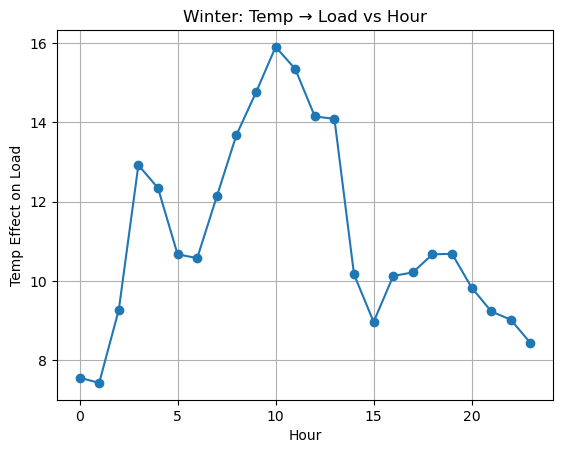

      hour      rh    temp     effect
0      0.0  68.550  22.250   7.443941
1      0.0  67.700  22.250   8.011583
2      0.0  68.150  22.200   7.491490
3      0.0  68.450  22.050   7.454677
4      1.0  67.400  22.050  11.788925
...    ...     ...     ...        ...
8635  22.0  53.575  27.275  10.939142
8636  23.0  53.425  27.100  10.998508
8637  23.0  52.825  27.050  11.861580
8638  23.0  52.325  27.000  10.654153
8639  23.0  52.150  26.900  10.260843

[8640 rows x 4 columns]
ATE Winter :  11.171412279184795


In [5]:
df_a = pd.read_csv("/Users/ameypatil/Desktop/Tata Power/data/winter_2025.csv")
df_a["datetime"] = pd.to_datetime(df_a["datetime"])



# Feature
df_a['hour'] = df_a ['datetime'].dt.hour

# Drop NaN
df_a = df_a.dropna()
 

Y = df_a["wdLoad"].values
T = df_a["temp"].values
X = df_a[["hour", "rh"]].values

model = CausalForestDML(
        model_y=RandomForestRegressor(),
        model_t=RandomForestRegressor(),
        random_state=42
    )
model.fit(Y, T, X=X)

effects = model.effect(X)
print(effects.shape)
print(effects)
df_effect = pd.DataFrame(X, columns=["hour", "rh"])
df_effect["temp"] = T
df_effect["effect"] = effects
df_a.head()
    # 🔥 Group by hour
hour_effect = df_effect.groupby("hour")["effect"].mean().reset_index()

plt.figure()
plt.plot(hour_effect["hour"], hour_effect["effect"], marker='o')

plt.xlabel("Hour")
plt.ylabel("Temp Effect on Load")
plt.title(f"Winter: Temp → Load vs Hour")

plt.grid()
plt.show()
print(df_effect)
ate = np.mean(effects)
print(f"ATE Winter : " , ate)


Processing: Winter
(8640,)
[-4.48959042 -4.5655555  -4.5655555  ... -1.20789456 -1.1313492
 -1.13183182]


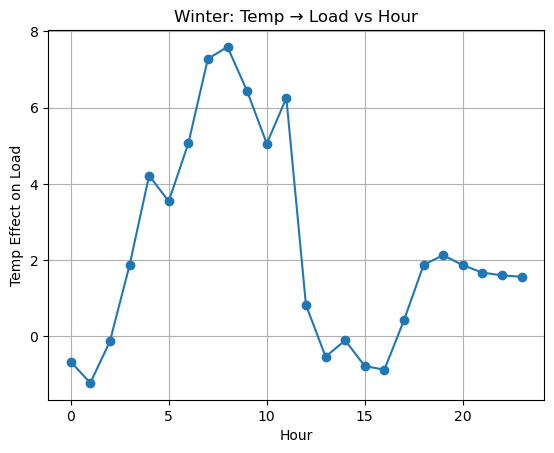

      hour         rh       temp    effect
0      0.0  78.066667  24.733333 -4.489590
1      0.0  78.133333  24.766667 -4.565555
2      0.0  78.133333  24.766667 -4.565555
3      0.0  78.333333  24.666667 -4.730976
4      1.0  78.633333  24.600000 -7.295018
...    ...        ...        ...       ...
8635  22.0  82.400000  20.900000 -1.082369
8636  23.0  81.800000  20.900000 -1.131832
8637  23.0  81.100000  20.800000 -1.207895
8638  23.0  82.800000  21.000000 -1.131349
8639  23.0  81.800000  21.100000 -1.131832

[8640 rows x 4 columns]
ATE Winter :  2.288433888462171

Processing: Summer
(8832,)
[11.22083942 14.79241543 15.28473146 ...  8.03516774  6.93090046
  6.55077755]


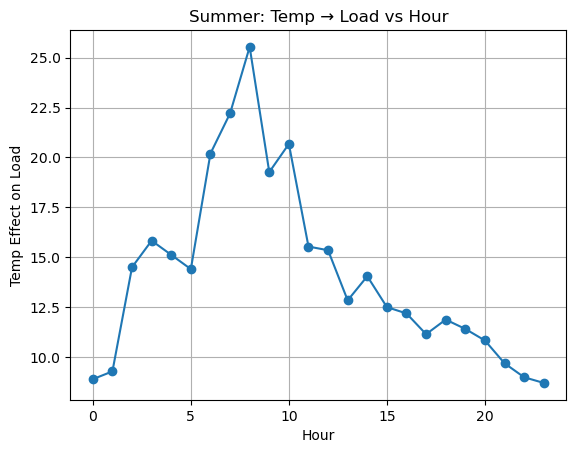

      hour      rh    temp     effect
0      0.0  51.900  26.850  11.220839
1      0.0  52.650  26.725  14.792415
2      0.0  52.725  26.475  15.284731
3      0.0  52.025  26.500  12.224927
4      1.0  52.325  26.375  14.575912
...    ...     ...     ...        ...
8827  22.0  88.025  27.525   9.731627
8828  23.0  88.575  27.475   9.041811
8829  23.0  89.400  27.450   8.035168
8830  23.0  89.725  27.525   6.930900
8831  23.0  89.825  27.675   6.550778

[8832 rows x 4 columns]
ATE Summer :  14.204203439698391

Processing: Monsoon
(11712,)
[9.03938975 5.91887552 7.55995615 ... 3.73419754 3.73419754 3.73419754]


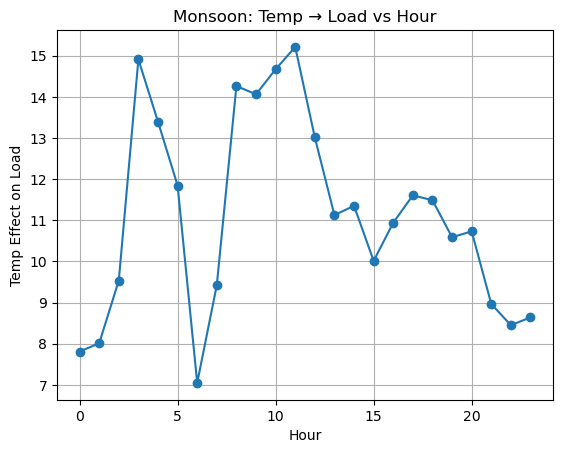

       hour      rh    temp    effect
0       0.0  90.475  27.750  9.039390
1       0.0  90.350  27.800  5.918876
2       0.0  90.125  27.900  7.559956
3       0.0  89.975  28.100  7.501926
4       1.0  89.725  28.275  3.793946
...     ...     ...     ...       ...
11707  22.0  99.500  24.300  2.702453
11708  23.0  99.500  24.400  3.734198
11709  23.0  99.500  24.400  3.734198
11710  23.0  99.500  24.400  3.734198
11711  23.0  99.500  24.350  3.734198

[11712 rows x 4 columns]
ATE Monsoon :  11.12950363234867

Processing: Autumn
(5856,)
[ 4.47225914 21.81323539 21.81323539 ...  9.58155404  8.1635185
 10.26888554]


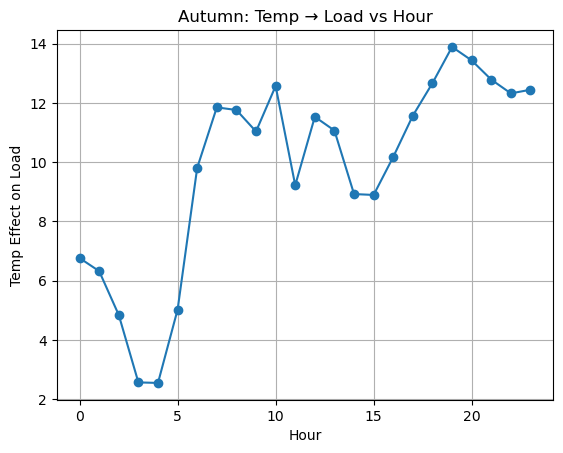

      hour    rh   temp     effect
0      0.0  99.5  24.35   4.472259
1      0.0  99.9  24.35  21.813235
2      0.0  99.9  24.35  21.813235
3      0.0  99.9  24.40  21.813235
4      1.0  99.9  24.40  22.657354
...    ...   ...    ...        ...
5851  22.0  64.4  21.80   8.202390
5852  23.0  63.5  21.75   9.457980
5853  23.0  63.7  21.60   9.581554
5854  23.0  64.4  21.50   8.163519
5855  23.0  67.1  21.45  10.268886

[5856 rows x 4 columns]
ATE Autumn :  9.74761722004191


In [13]:
for season in seasons:

    print("\nProcessing:", season)

    df_s = df[df["Season"] == season].dropna(subset=["wdLoad", "temp", "rh", "hour"])
    if len(df_s) < 50:
        continue

    Y = df_s["wdLoad"].values
    T = df_s["temp"].values
    X = df_s[["hour", "rh"]].values

    model = CausalForestDML(
        model_y=RandomForestRegressor(),
        model_t=RandomForestRegressor(),
        random_state=42
    )
    model.fit(Y, T, X=X)

    effects = model.effect(X)
    print(effects.shape)
    print(effects)
    df_effect = pd.DataFrame(X, columns=["hour", "rh"])
    df_effect["temp"] = T
    df_effect["effect"] = effects
    df.head()
    # 🔥 Group by hour
    hour_effect = df_effect.groupby("hour")["effect"].mean().reset_index()

    plt.figure()
    plt.plot(hour_effect["hour"], hour_effect["effect"], marker='o')

    plt.xlabel("Hour")
    plt.ylabel("Temp Effect on Load")
    plt.title(f"{season}: Temp → Load vs Hour")

    plt.grid()
    plt.show()
    print(df_effect)
    ate = np.mean(effects)
    print(f"ATE {season} : " , ate)

In [10]:
df.head(
)

,_id_x,datetime,wdLoad,_id_y,temp,rh,hour,Season
245494,67765a8757144a56a720e326,2025-01-01 00:00:00+00:00,276.186445,6776626d57144a56a720e3eb,24.733333,78.066667,0,Winter
245495,67765a8757144a56a720e327,2025-01-01 00:15:00+00:00,279.700694,6776626d57144a56a720e3ec,24.766667,78.133333,0,Winter
245496,67765a8757144a56a720e328,2025-01-01 00:30:00+00:00,283.051573,6776626d57144a56a720e3ed,24.766667,78.133333,0,Winter
245497,67765a8757144a56a720e329,2025-01-01 00:45:00+00:00,286.960382,6776626d57144a56a720e3ee,24.666667,78.333333,0,Winter
245498,67765a8757144a56a720e32a,2025-01-01 01:00:00+00:00,292.949629,6776626d57144a56a720e3ef,24.600000,78.633333,1,Winter


CASE 2: RH → Load

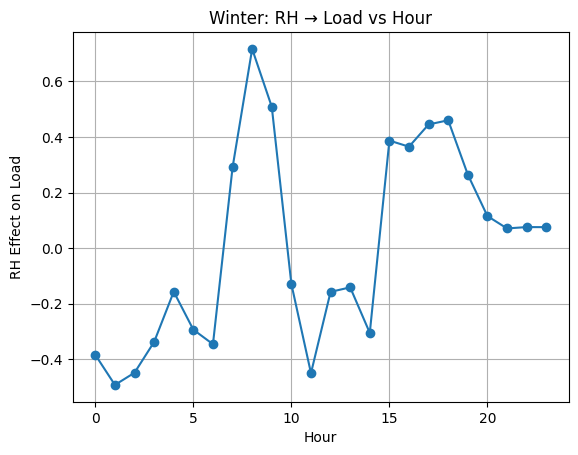

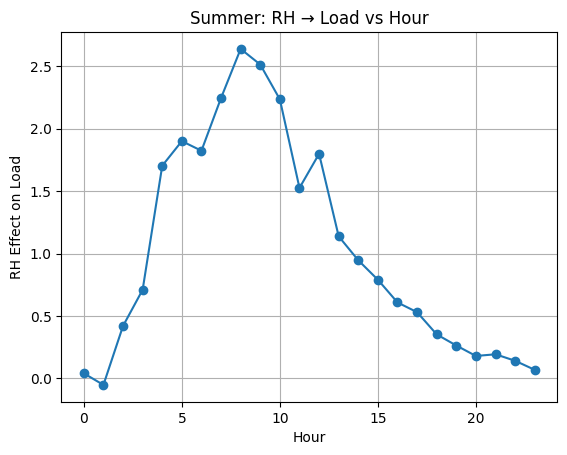

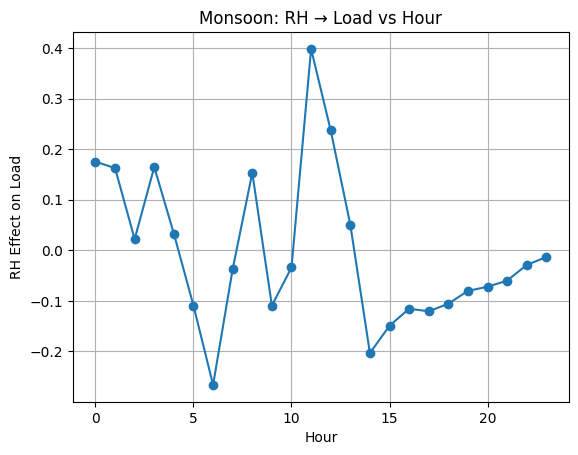

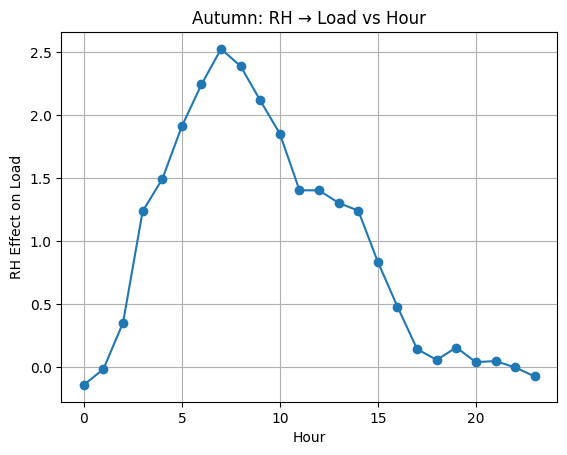

In [23]:
for season in seasons:

    df_s = df[df["Season"] == season].dropna(subset=["wdLoad", "temp", "rh", "hour"])
    if len(df_s) < 50:
        continue

    Y = df_s["wdLoad"].values
    T = df_s["rh"].values
    X = df_s[["temp", "hour"]].values

    model = CausalForestDML(
        model_y=RandomForestRegressor(),
        model_t=RandomForestRegressor(),
        random_state=42
    )

    model.fit(Y, T, X=X)

    effects = model.effect(X)

    df_effect = pd.DataFrame(X, columns=["temp", "hour"])
    df_effect["rh"] = T
    df_effect["effect"] = effects

    hour_effect = df_effect.groupby("hour")["effect"].mean().reset_index()

    plt.figure()
    plt.plot(hour_effect["hour"], hour_effect["effect"], marker='o')

    plt.xlabel("Hour")
    plt.ylabel("RH Effect on Load")
    plt.title(f"{season}: RH → Load vs Hour")

    plt.grid()
    plt.show()

CASE 3: Hour → Load


Processing: Winter


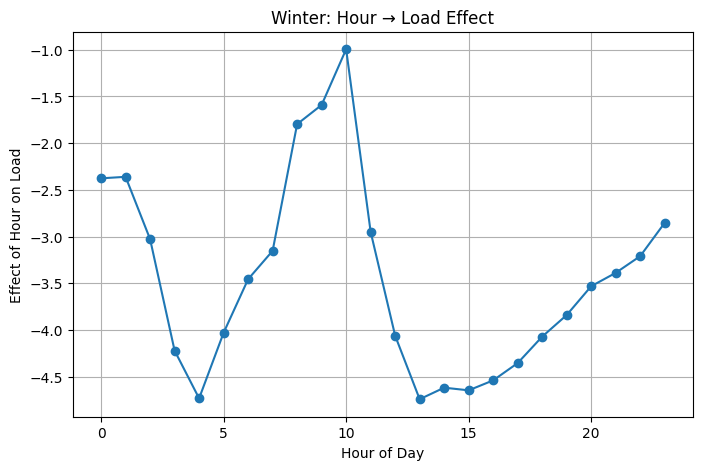


Processing: Summer


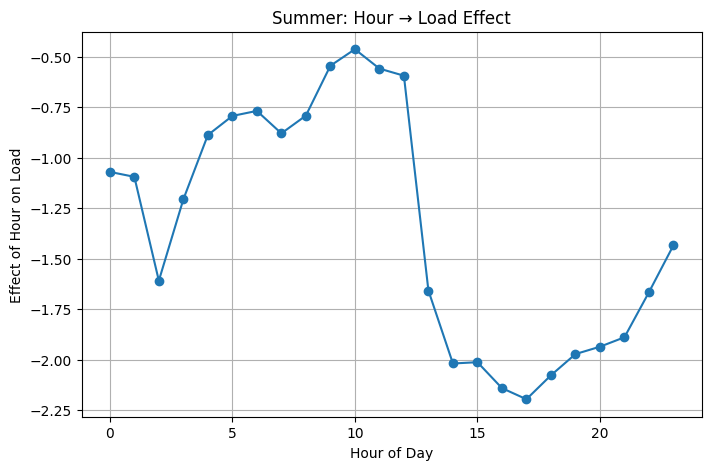


Processing: Monsoon


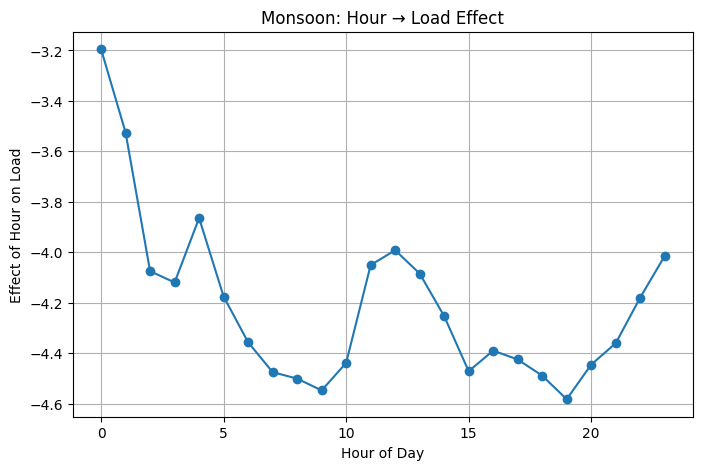


Processing: Autumn


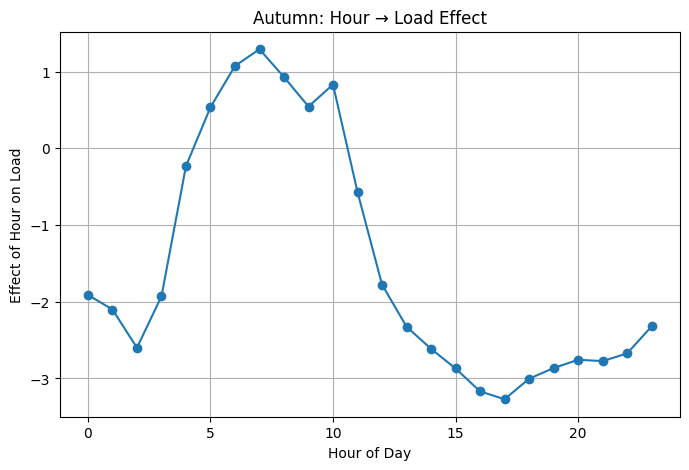

In [26]:
import matplotlib.pyplot as plt

seasons = ["Winter", "Summer", "Monsoon", "Autumn"]

for season in seasons:

    print("\nProcessing:", season)

    df_s = df[df["Season"] == season].copy()
    df_s = df_s.dropna(subset=["wdLoad", "temp", "rh", "hour"])

    if len(df_s) < 50:
        print("Skipped")
        continue

    # -------------------------------
    # 🔹 Model training (Hour → Load)
    # -------------------------------
    Y = df_s["wdLoad"].values
    T = df_s["hour"].values          # Treatment = hour
    X = df_s[["temp", "rh"]].values  # Controls

    model = CausalForestDML(
        model_y=RandomForestRegressor(),
        model_t=RandomForestRegressor(),
        n_estimators=100,
        min_samples_leaf=10,
        random_state=42
    )

    model.fit(Y, T, X=X)

    # -------------------------------
    # 🔹 Get Individual Effects
    # -------------------------------
    effects = model.effect(X)

    df_effect = pd.DataFrame(X, columns=["temp", "rh"])
    df_effect["hour"] = T
    df_effect["effect"] = effects

    # -------------------------------
    # 🔹 Group by hour (KEY STEP)
    # -------------------------------
    hour_effect = df_effect.groupby("hour")["effect"].mean().reset_index()

    # -------------------------------
    # 🔹 Plot
    # -------------------------------
    plt.figure(figsize=(8,5))
    plt.plot(hour_effect["hour"], hour_effect["effect"], marker='o')

    plt.xlabel("Hour of Day")
    plt.ylabel("Effect of Hour on Load")
    plt.title(f"{season}: Hour → Load Effect")

    plt.grid()
    plt.show()

CASE 4: Temp + RH → Load

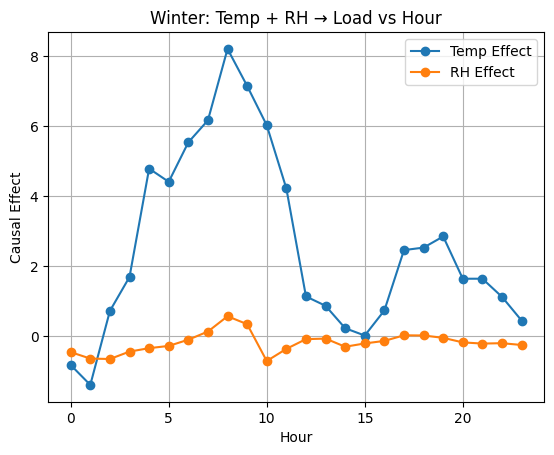

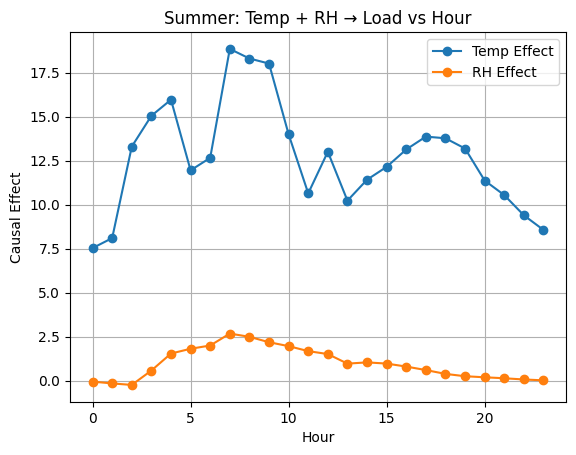

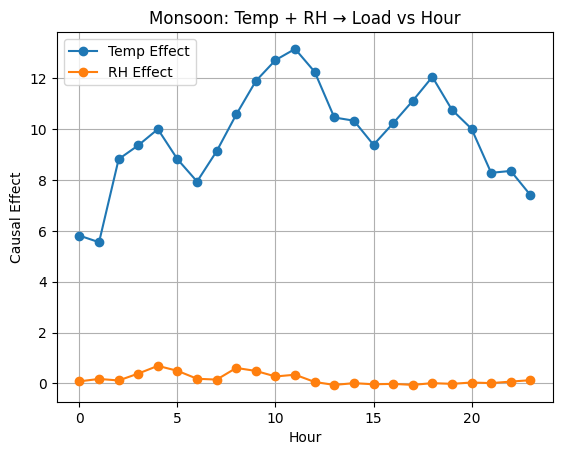

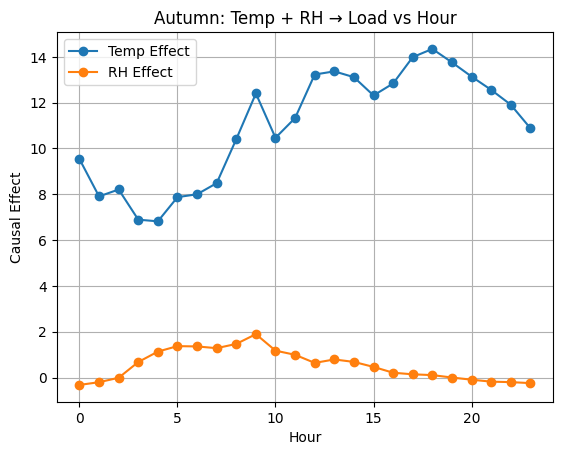

In [25]:
for season in seasons:

    df_s = df[df["Season"] == season].dropna(subset=["wdLoad", "temp", "rh", "hour"])
    if len(df_s) < 50:
        continue

    Y = df_s["wdLoad"].values
    T = df_s[["temp", "rh"]].values
    X = df_s[["hour"]].values

    model = CausalForestDML(
        model_y=RandomForestRegressor(),
        model_t=RandomForestRegressor(),
        random_state=42
    )

    model.fit(Y, T, X=X)

    effects = model.const_marginal_effect(X)

    df_effect = pd.DataFrame(X, columns=["hour"])
    df_effect["temp"] = T[:, 0]
    df_effect["rh"] = T[:, 1]

    df_effect["effect_temp"] = effects[:, 0]
    df_effect["effect_rh"] = effects[:, 1]

    hour_effect = df_effect.groupby("hour")[["effect_temp", "effect_rh"]].mean().reset_index()

    plt.figure()

    plt.plot(hour_effect["hour"], hour_effect["effect_temp"], marker='o', label="Temp Effect")
    plt.plot(hour_effect["hour"], hour_effect["effect_rh"], marker='o', label="RH Effect")

    plt.xlabel("Hour")
    plt.ylabel("Causal Effect")
    plt.title(f"{season}: Temp + RH → Load vs Hour")

    plt.legend()
    plt.grid()
    plt.show()